<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost catboost optuna lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.5 MB/s eta 0:00:00


In [ ]:
!pip install optuna

In [ ]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 3.5 MB/s eta 0:00:00



--- [1-1. Optuna パラメータ最適化 (LightGBM)] ---

--- [1-2. Optuna パラメータ最適化 (XGBoost)] ---

--- [1-3. Optuna パラメータ最適化 (CatBoost)] ---

--- [2. 学習フェーズ開始 (3モデル独立 Early Stopping アンサンブル)] ---
>> Running Seed: 42...
>> Running Seed: 2023...
>> Running Seed: 777...
✅ 学習完了: 最終 OOF AUC: 0.8749

🏆 最終ローカルCVスコア (AUC): 0.8749
📉 最終損失 (Log Loss): 0.3334


--- [3. 予測フェーズ開始] ---
✅ 予測完了: 計 45 個のモデルによるアンサンブル予測を実行しました。

--- [4. エラー分析 (損失原因の特定)] ---
▼ 全体のエラー件数 (is_error = 1): 247 件 / 1568 件

▼ 損失原因度ランキング トップ5:
                    Feature  Error_Importance
0               total_spend         32.904130
1  days_since_last_purchase         21.747834
2         campaign_affinity         20.502949
3   days_since_registration         12.164664
4        luxury_spend_ratio          4.157523

--- [5. 特徴量重要度の算出] ---


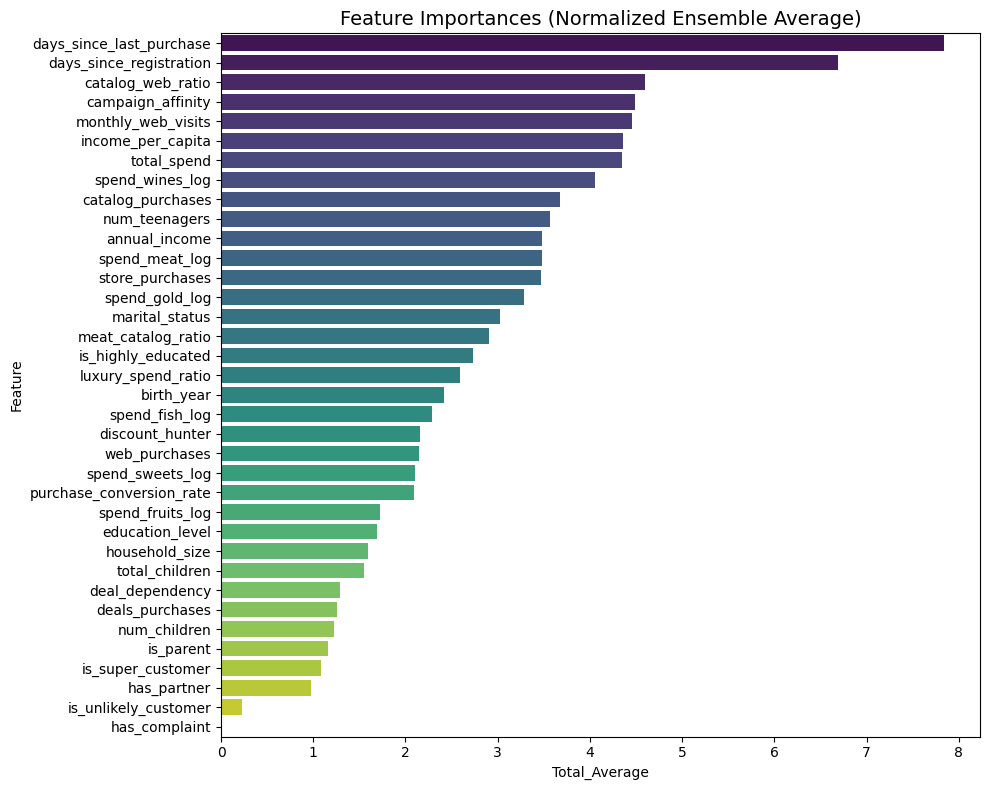


✅ 全工程完了: 'final_submission_trinity.csv' を出力しました！


In [15]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ==========================================
# 0. 絶対にリークしない事前処理（行単位のみ・バグ修正版）
# ==========================================
def preprocess_safe_row_wise(df):
    df = df.copy()
    base_date = pd.to_datetime('2015-01-01')

    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)

    # 潜在的バグ対策：購買系カラムの存在チェックと合計の安全な計算
    purchase_cols = ['store_purchases', 'web_purchases', 'catalog_purchases']
    has_purchases = all(c in df.columns for c in purchase_cols)
    if has_purchases:
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
    else:
        total_purchases = None

    if all(c in df.columns for c in ['spend_wines', 'spend_meat', 'days_since_last_purchase']):
        raw_loyalty = (df['spend_wines'] + df['spend_meat']) / (df['days_since_last_purchase'] + 1)
        df['recent_loyalty'] = np.log1p(raw_loyalty)

    if all(c in df.columns for c in ['spend_meat', 'catalog_purchases']):
        raw_meat_ratio = df['spend_meat'] / (df['catalog_purchases'] + 1)
        df['meat_catalog_ratio'] = np.log1p(raw_meat_ratio)

    if has_purchases and 'deals_purchases' in df.columns:
        df['discount_hunter'] = df['deals_purchases'] / (total_purchases + 1)
        if 'recent_loyalty' in df.columns:
            df['campaign_affinity'] = df['recent_loyalty'] * df['discount_hunter']

    # ペルソナ特徴量
    if all(c in df.columns for c in ['num_children', 'num_teenagers']):
        df['total_children'] = df['num_children'] + df['num_teenagers']
        df['is_parent'] = (df['total_children'] > 0).astype(int)

    if 'marital_status' in df.columns and 'total_children' in df.columns:
        partner_status = ['Married', 'Together']
        df['has_partner'] = df['marital_status'].isin(partner_status).astype(int)
        df['household_size'] = 1 + df['has_partner'] + df['total_children']

        if 'annual_income' in df.columns:
            df['income_per_capita'] = df['annual_income'] / df['household_size']

    if 'education_level' in df.columns:
        df['is_highly_educated'] = df['education_level'].isin(['Master', 'Doctorate']).astype(int)

    spend_cols = [c for c in df.columns if c.startswith('spend_') and not c.endswith('_log')]
    if all(c in df.columns for c in ['spend_wines', 'spend_meat']) and len(spend_cols) > 0:
        df['total_spend'] = df[spend_cols].sum(axis=1)
        df['luxury_spend_ratio'] = (df['spend_wines'] + df['spend_meat']) / (df['total_spend'] + 1)

    # 行動心理・特徴量
    if all(c in df.columns for c in ['catalog_purchases', 'web_purchases']):
        df['catalog_web_ratio'] = df['catalog_purchases'] / (df['web_purchases'] + 1)

    if has_purchases and 'monthly_web_visits' in df.columns:
        df['purchase_conversion_rate'] = total_purchases / (df['monthly_web_visits'] + 1)

    if has_purchases and 'deals_purchases' in df.columns:
        df['deal_dependency'] = df['deals_purchases'] / (total_purchases + 1)

    # 金額系Log変換
    spend_cols = [c for c in df.columns if c.startswith('spend_')]
    for col in spend_cols:
        df[col + '_log'] = np.log1p(df[col])

    return df

# ==========================================
# 1-1. LightGBM パラメータ最適化
# ==========================================
def tune_lightgbm_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1-1. Optuna パラメータ最適化 (LightGBM)] ---")

    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'class_weight': 'balanced',
            'verbose': -1
        }

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            affinity_threshold = X_tr['campaign_affinity'].quantile(0.95) if 'campaign_affinity' in X_tr.columns else 0
            for temp_df in [X_tr, X_va]:
                temp_df['is_unlikely_customer'] = ((temp_df['num_children'] >= 2) & (temp_df['annual_income'] < med)).astype(int)
                if 'campaign_affinity' in temp_df.columns:
                    temp_df['is_super_customer'] = ((temp_df['campaign_affinity'] > affinity_threshold) & (temp_df['annual_income'] > med)).astype(int)

            cols = ['education_level', 'marital_status']
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[cols] = enc.fit_transform(X_tr[cols])
            X_va[cols] = enc.transform(X_va[cols])

            model = LGBMClassifier(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
            )
            oof[va_idx] = model.predict_proba(X_va)[:, 1]

        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({
        'random_state': 42,
        'n_estimators': 3000,  # 本学習でEarly Stoppingさせるため大きめに設定
        'class_weight': 'balanced',
        'verbose': -1
    })
    return best_params

# ==========================================
# 1-2. XGBoost パラメータ最適化
# ==========================================
def tune_xgboost_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1-2. Optuna パラメータ最適化 (XGBoost)] ---")
    ratio = float(np.sum(y == 0)) / np.sum(y == 1)

    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight': ratio,
            'eval_metric': 'logloss',
            'early_stopping_rounds': 30
        }

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            affinity_threshold = X_tr['campaign_affinity'].quantile(0.95) if 'campaign_affinity' in X_tr.columns else 0
            for temp_df in [X_tr, X_va]:
                temp_df['is_unlikely_customer'] = ((temp_df['num_children'] >= 2) & (temp_df['annual_income'] < med)).astype(int)
                if 'campaign_affinity' in temp_df.columns:
                    temp_df['is_super_customer'] = ((temp_df['campaign_affinity'] > affinity_threshold) & (temp_df['annual_income'] > med)).astype(int)

            cols = ['education_level', 'marital_status']
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[cols] = enc.fit_transform(X_tr[cols])
            X_va[cols] = enc.transform(X_va[cols])

            model = XGBClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            oof[va_idx] = model.predict_proba(X_va)[:, 1]

        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({
        'random_state': 42,
        'n_estimators': 3000,
        'scale_pos_weight': ratio,
        'eval_metric': 'logloss',
        'early_stopping_rounds': 30
    })
    return best_params

# ==========================================
# 1-3. CatBoost パラメータ最適化
# ==========================================
def tune_catboost_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1-3. Optuna パラメータ最適化 (CatBoost)] ---")

    def objective(trial):
        params = {
            'random_state': 42,
            'iterations': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'depth': trial.suggest_int('depth', 3, 8),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'auto_class_weights': 'Balanced',
            'early_stopping_rounds': 30,
            'verbose': False
        }

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))
        categorical_cols = ['education_level', 'marital_status']

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            affinity_threshold = X_tr['campaign_affinity'].quantile(0.95) if 'campaign_affinity' in X_tr.columns else 0
            for temp_df in [X_tr, X_va]:
                temp_df['is_unlikely_customer'] = ((temp_df['num_children'] >= 2) & (temp_df['annual_income'] < med)).astype(int)
                if 'campaign_affinity' in temp_df.columns:
                    temp_df['is_super_customer'] = ((temp_df['campaign_affinity'] > affinity_threshold) & (temp_df['annual_income'] > med)).astype(int)

            X_tr[categorical_cols] = X_tr[categorical_cols].astype(str)
            X_va[categorical_cols] = X_va[categorical_cols].astype(str)

            params['cat_features'] = categorical_cols
            model = CatBoostClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)])
            oof[va_idx] = model.predict_proba(X_va)[:, 1]

        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({
        'random_state': 42,
        'iterations': 3000,
        'auto_class_weights': 'Balanced',
        'early_stopping_rounds': 30,
        'verbose': False
    })
    return best_params

# ==========================================
# 2. 学習フェーズ (各モデル独立 Early Stopping 設計)
# ==========================================
def train_models(X_raw, y, lgb_params, xgb_params, cat_params, seeds=[42, 2023, 777], n_splits=5):
    print(f"\n--- [2. 学習フェーズ開始 (3モデル独立 Early Stopping アンサンブル)] ---")
    artifacts = []
    oof_preds_ensemble = np.zeros(len(X_raw))

    for seed in seeds:
        print(f">> Running Seed: {seed}...")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof_seed = np.zeros(len(X_raw))

        # シードごとに固有のパラメータコピーを作成
        lgb_curr = lgb_params.copy()
        xgb_curr = xgb_params.copy()
        cat_curr = cat_params.copy()

        lgb_curr['random_state'] = seed
        xgb_curr['random_state'] = seed
        cat_curr['random_state'] = seed

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
            X_tr, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
            X_va, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

            X_tr_cat = X_tr.copy()
            X_va_cat = X_va.copy()
            categorical_cols = ['education_level', 'marital_status']

            # 欠損値補完
            income_median = X_tr['annual_income'].median()
            for temp_df in [X_tr, X_va, X_tr_cat, X_va_cat]:
                temp_df['annual_income'] = temp_df['annual_income'].fillna(income_median)

            # CVループ内での安全な特徴量生成
            affinity_threshold = X_tr['campaign_affinity'].quantile(0.95) if 'campaign_affinity' in X_tr.columns else 0
            for temp_df in [X_tr, X_va, X_tr_cat, X_va_cat]:
                temp_df['is_unlikely_customer'] = ((temp_df['num_children'] >= 2) & (temp_df['annual_income'] < income_median)).astype(int)
                if 'campaign_affinity' in temp_df.columns:
                    temp_df['is_super_customer'] = ((temp_df['campaign_affinity'] > affinity_threshold) & (temp_df['annual_income'] > income_median)).astype(int)

            # CatBoost用の文字列変換
            X_tr_cat[categorical_cols] = X_tr_cat[categorical_cols].astype(str)
            X_va_cat[categorical_cols] = X_va_cat[categorical_cols].astype(str)

            # LGBM/XGB用の数値エンコーディング
            encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[categorical_cols] = encoder.fit_transform(X_tr[categorical_cols])
            X_va[categorical_cols] = encoder.transform(X_va[categorical_cols])

            # 各アルゴリズムをそのFoldの検証データで最適にEarly Stoppingさせる
            model_lgb = LGBMClassifier(**lgb_curr)
            model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])

            model_xgb = XGBClassifier(**xgb_curr)
            model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

            cat_curr['cat_features'] = categorical_cols
            model_cat = CatBoostClassifier(**cat_curr)
            model_cat.fit(X_tr_cat, y_tr, eval_set=[(X_va_cat, y_va)], verbose=False)

            # 各モデルの予測値を平均（ブレンド）
            fold_val_preds = (
                model_lgb.predict_proba(X_va)[:, 1] +
                model_xgb.predict_proba(X_va)[:, 1] +
                model_cat.predict_proba(X_va_cat)[:, 1]
            ) / 3.0

            oof_seed[val_idx] = fold_val_preds

            # テスト推論用に学習時の統計量と個別に学習を完了したモデル群を保存
            artifacts.append({
                'seed': seed,
                'fold': fold,
                'preprocessors': {
                    'income_median': income_median,
                    'affinity_threshold': affinity_threshold,
                    'encoder': encoder,
                    'cat_cols': categorical_cols
                },
                'models': {
                    'LightGBM': model_lgb,
                    'XGBoost': model_xgb,
                    'CatBoost': model_cat
                },
                'feature_names': list(X_tr.columns)
            })

        oof_preds_ensemble += oof_seed / len(seeds)

    print(f"✅ 学習完了: 最終 OOF AUC: {roc_auc_score(y, oof_preds_ensemble):.4f}")
    return artifacts, oof_preds_ensemble

# ==========================================
# 3. 予測フェーズ (Predict)
# ==========================================
def predict_models(X_test_raw, artifacts):
    print("\n--- [3. 予測フェーズ開始] ---")
    final_test_preds = np.zeros(len(X_test_raw))
    total_models = 0

    for artifact in artifacts:
        X_te = X_test_raw.copy()
        X_te_cat = X_test_raw.copy()

        preps = artifact['preprocessors']
        models = artifact['models']

        inc_med = preps['income_median']
        aff_th = preps['affinity_threshold']

        # テストデータに対しても学習時の統計量を厳密に適用（リークの完全防止）
        for temp_df in [X_te, X_te_cat]:
            temp_df['annual_income'] = temp_df['annual_income'].fillna(inc_med)
            temp_df['is_unlikely_customer'] = ((temp_df['num_children'] >= 2) & (temp_df['annual_income'] < inc_med)).astype(int)
            if 'campaign_affinity' in temp_df.columns:
                temp_df['is_super_customer'] = ((temp_df['campaign_affinity'] > aff_th) & (temp_df['annual_income'] > inc_med)).astype(int)

        X_te_cat[preps['cat_cols']] = X_te_cat[preps['cat_cols']].astype(str)
        X_te[preps['cat_cols']] = preps['encoder'].transform(X_te[preps['cat_cols']])

        for name, model in models.items():
            if name == 'CatBoost':
                final_test_preds += model.predict_proba(X_te_cat)[:, 1]
            else:
                final_test_preds += model.predict_proba(X_te)[:, 1]
            total_models += 1

    final_test_preds /= total_models
    print(f"✅ 予測完了: 計 {total_models} 個のモデルによるアンサンブル予測を実行しました。")
    return final_test_preds

# ==========================================
# 4. & 5. 可視化関数
# ==========================================
def analyze_error_patterns(X_raw, y, oof_preds):
    print("\n--- [4. エラー分析 (損失原因の特定)] ---")
    error_df = X_raw.copy()
    error_df['target'] = y
    error_df['pred_class'] = (oof_preds >= 0.5).astype(int)
    error_df['is_error'] = (error_df['target'] != error_df['pred_class']).astype(int)
    print(f"▼ 全体のエラー件数 (is_error = 1): {error_df['is_error'].sum()} 件 / {len(error_df)} 件")

    X_error = X_raw.copy()
    X_error['annual_income'] = X_error['annual_income'].fillna(X_error['annual_income'].median())
    cols = ['education_level', 'marital_status']
    X_error[cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X_error[cols])

    inc_med = X_error['annual_income'].median()
    aff_th = X_error['campaign_affinity'].quantile(0.95) if 'campaign_affinity' in X_error.columns else 0
    X_error['is_unlikely_customer'] = ((X_error['num_children'] >= 2) & (X_error['annual_income'] < inc_med)).astype(int)
    if 'campaign_affinity' in X_error.columns:
         X_error['is_super_customer'] = ((X_error['campaign_affinity'] > aff_th) & (X_error['annual_income'] > inc_med)).astype(int)

    error_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
    error_model.fit(X_error, error_df['is_error'])

    error_importance = pd.DataFrame({'Feature': X_error.columns, 'Error_Importance': error_model.feature_importances_ * 100}).sort_values(by='Error_Importance', ascending=False).reset_index(drop=True)
    print("\n▼ 損失原因度ランキング トップ5:")
    print(error_importance.head(5))
    return error_importance

def plot_feature_importances(artifacts):
    print("\n--- [5. 特徴量重要度の算出] ---")
    f_names = artifacts[0]['feature_names']
    importance_df = pd.DataFrame({'Feature': f_names})
    total_imps = np.zeros(len(f_names))
    total_models = 0
    scaler = MinMaxScaler()

    for art in artifacts:
        for name, model in art['models'].items():
            raw_imp = model.feature_importances_
            scaled_imp = scaler.fit_transform(raw_imp.reshape(-1, 1)).flatten()
            total_imps += scaled_imp
            total_models += 1

    importance_df['Total_Average'] = (total_imps / total_models)
    importance_df['Total_Average'] = (importance_df['Total_Average'] / importance_df['Total_Average'].sum()) * 100
    importance_df = importance_df.sort_values(by='Total_Average', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Total_Average', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importances (Normalized Ensemble Average)', fontsize=14)
    plt.tight_layout()
    plt.show()

# ==========================================
# メイン実行ブロック
# ==========================================
if __name__ == "__main__":
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    train_df = preprocess_safe_row_wise(train_data)
    test_df = preprocess_safe_row_wise(test_data)

    cols_to_drop = ['customer_id', 'target', 'recent_loyalty',
                    'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold']

    test_cols_to_drop = [c for c in cols_to_drop if c != 'target']

    X_raw = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
    y = train_df['target']
    X_test_raw = test_df.drop(columns=[c for c in test_cols_to_drop if c in test_df.columns], errors='ignore')

    # 各モデルのハイパーパラメータを個別に最適化（不整合の解消）
    best_lgb_params = tune_lightgbm_with_optuna(X_raw, y, n_trials=10)
    best_xgb_params = tune_xgboost_with_optuna(X_raw, y, n_trials=10)
    best_cat_params = tune_catboost_with_optuna(X_raw, y, n_trials=10)

    # 最適化されたそれぞれのパラメータを投入して本学習を実行
    artifacts, oof_predictions = train_models(X_raw, y, best_lgb_params, best_xgb_params, best_cat_params)

    # -----------------------------------------------------
    # 【追加箇所】最終的なローカルのCVスコアと最終的な損失の計算・表示
    # -----------------------------------------------------
    final_cv_auc = roc_auc_score(y, oof_predictions)
    final_cv_loss = log_loss(y, oof_predictions)

    print("\n==========================================")
    print(f"🏆 最終ローカルCVスコア (AUC): {final_cv_auc:.4f}")
    print(f"📉 最終損失 (Log Loss): {final_cv_loss:.4f}")
    print("==========================================\n")
    # -----------------------------------------------------

    final_predictions = predict_models(X_test_raw, artifacts)

    analyze_error_patterns(X_raw, y, oof_predictions)
    plot_feature_importances(artifacts)

    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_submission_trinity.csv', index=False)
    print("\n✅ 全工程完了: 'final_submission_trinity.csv' を出力しました！")